## 1. Introduction

This project develops a personalised workout recommendation system using two machine learning techniques: Long Short-Term Memory (LSTM) networks and Reinforcement Learning (RL). The aim is to estimate a user's fatigue level from historical Fitbit data and then recommend an appropriate workout intensity based on that predicted condition.

The LSTM component is used to model temporal relationships in activity and sleep data, while the RL component is used to learn a workout recommendation policy that balances exercise progression and recovery.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Dataset Description

The project uses the Fitbit open-source dataset. Two files are selected for this work:

- `dailyActivity_merged.csv`, which contains daily activity variables such as steps, calories, and active minutes
- `minuteSleep_merged.csv`, which contains sleep records that can be aggregated into daily sleep duration

These datasets are used to construct daily time-series features for fatigue prediction.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

activity = pd.read_csv("/content/data/dailyActivity_merged.csv")
sleep = pd.read_csv("/content/data/minuteSleep_merged.csv")

print(activity.head())
print(sleep.head())

           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    3/25/2016       11004           7.11             7.11   
1  1503960366    3/26/2016       17609          11.55            11.55   
2  1503960366    3/27/2016       12736           8.53             8.53   
3  1503960366    3/28/2016       13231           8.93             8.93   
4  1503960366    3/29/2016       12041           7.85             7.85   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                2.57                      0.46   
1                       0.0                6.92                      0.73   
2                       0.0                4.66                      0.16   
3                       0.0                3.19                      0.79   
4                       0.0                2.16                      1.09   

   LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  \
0                 4.07

## 3. Data Preprocessing and Feature Engineering

The raw Fitbit data cannot be used directly for machine learning because activity and sleep are stored in separate files and at different temporal resolutions. Therefore, preprocessing is required to construct a single daily-level dataset.

The preprocessing includes:
- converting date columns into a consistent format
- aggregating minute-level sleep records into daily sleep duration
- merging the activity and sleep datasets
- creating derived variables such as activity load and fatigue score

In [3]:
activity["ActivityDate"] = pd.to_datetime(activity["ActivityDate"])
# Convert to datetime
sleep["date"] = pd.to_datetime(sleep["date"])

# Extract ONLY the day (remove time)
sleep["day"] = sleep["date"].dt.date

# Aggregate per day
sleep_daily = sleep.groupby(["Id", "day"])["value"].sum().reset_index()

sleep_daily.rename(columns={
    "value": "sleep_minutes",
    "day": "date"
}, inplace=True)

# Convert to hours
sleep_daily["sleep_hours"] = sleep_daily["sleep_minutes"] / 60

print(sleep_daily["sleep_hours"].describe())

count    467.000000
mean       7.695039
std        3.050605
min        0.100000
25%        6.608333
50%        8.050000
75%        9.425000
max       20.016667
Name: sleep_hours, dtype: float64


In [4]:
activity["ActivityDate"] = pd.to_datetime(activity["ActivityDate"])
activity["date"] = activity["ActivityDate"].dt.date

In [5]:
data = pd.merge(activity, sleep_daily, on=["Id", "date"], how="inner")

print(data.head())

           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366   2016-03-25       11004           7.11             7.11   
1  1503960366   2016-03-26       17609          11.55            11.55   
2  1503960366   2016-03-27       12736           8.53             8.53   
3  1503960366   2016-03-28       13231           8.93             8.93   
4  1503960366   2016-03-29       12041           7.85             7.85   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                2.57                      0.46   
1                       0.0                6.92                      0.73   
2                       0.0                4.66                      0.16   
3                       0.0                3.19                      0.79   
4                       0.0                2.16                      1.09   

   LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  \
0                 4.07

In [6]:
data["activity_load"] = (
    data["VeryActiveMinutes"] * 2 +
    data["FairlyActiveMinutes"] * 1.5 +
    data["LightlyActiveMinutes"]
)

print(data[[
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "activity_load"
]].head())

   VeryActiveMinutes  FairlyActiveMinutes  LightlyActiveMinutes  activity_load
0                 33                   12                   205          289.0
1                 89                   17                   274          477.5
2                 56                    5                   268          387.5
3                 39                   20                   224          332.0
4                 28                   28                   243          341.0


In [7]:
data["fatigue_score"] = (
    data["activity_load"] / 60 -
    data["sleep_hours"] * 0.5
)

print(data[[
    "activity_load",
    "sleep_hours",
    "fatigue_score"
]].head())

   activity_load  sleep_hours  fatigue_score
0          289.0     7.066667       1.283333
1          477.5     8.516667       3.700000
2          387.5     8.883333       2.016667
3          332.0     1.350000       4.858333
4          341.0     6.850000       2.258333


In [8]:
dataset = data[[
    "Id",
    "date",
    "TotalSteps",
    "activity_load",
    "SedentaryMinutes",
    "Calories",
    "sleep_hours",
    "fatigue_score"
]].copy()

print(dataset.head())

           Id        date  TotalSteps  activity_load  SedentaryMinutes  \
0  1503960366  2016-03-25       11004          289.0               804   
1  1503960366  2016-03-26       17609          477.5               588   
2  1503960366  2016-03-27       12736          387.5               605   
3  1503960366  2016-03-28       13231          332.0              1080   
4  1503960366  2016-03-29       12041          341.0               763   

   Calories  sleep_hours  fatigue_score  
0      1819     7.066667       1.283333  
1      2154     8.516667       3.700000  
2      1944     8.883333       2.016667  
3      1932     1.350000       4.858333  
4      1886     6.850000       2.258333  


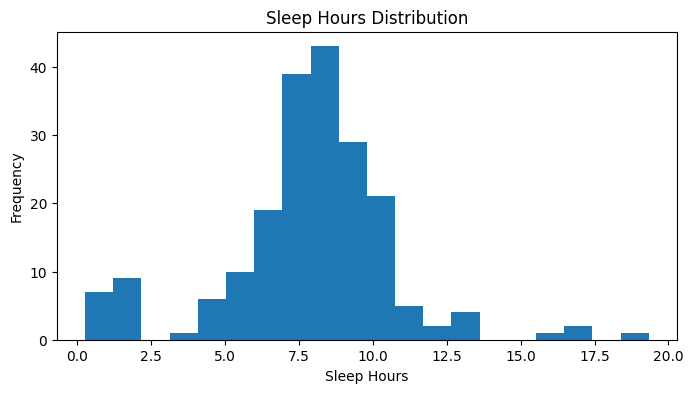

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(dataset["sleep_hours"], bins=20)
plt.title("Sleep Hours Distribution")
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")
plt.show()



In [10]:
dataset.to_csv("processed_fitbit_data.csv", index=False)

## 4. LSTM-Based Fatigue Prediction

The processed Fitbit dataset is now transformed into a format suitable for sequential modelling. Since LSTM networks are designed to learn temporal dependencies, the daily observations must be converted into rolling time-series windows.

In this project, sequences of previous days are used to predict the fatigue score of the following day. This enables the model to capture how recent activity and sleep patterns influence short-term recovery.

### 4.1 Temporal Ordering of the Dataset

Before constructing time-series sequences, the dataset is sorted by user ID and date to ensure that each sequence preserves the correct chronological order.

In [11]:
dataset["date"] = pd.to_datetime(dataset["date"])
dataset = dataset.sort_values(["Id", "date"]).reset_index(drop=True)

dataset.head()

,Id,date,TotalSteps,activity_load,SedentaryMinutes,Calories,sleep_hours,fatigue_score
0,1503960366,2016-03-25,11004,289.0,804,1819,7.066667,1.283333
1,1503960366,2016-03-26,17609,477.5,588,2154,8.516667,3.700000
2,1503960366,2016-03-27,12736,387.5,605,1944,8.883333,2.016667
3,1503960366,2016-03-28,13231,332.0,1080,1932,1.350000,4.858333
4,1503960366,2016-03-29,12041,341.0,763,1886,6.850000,2.258333


### 4.2 Input Features and Prediction Target

The LSTM model uses daily activity and sleep variables as input features. The target variable is the fatigue score, which represents the value to be predicted for the following day.

In [12]:
feature_cols = [
    "TotalSteps",
    "activity_load",
    "SedentaryMinutes",
    "Calories",
    "sleep_hours"
]

target_col = "fatigue_score"

print(feature_cols)

['TotalSteps', 'activity_load', 'SedentaryMinutes', 'Calories', 'sleep_hours']


### 4.3 Feature Scaling

The input features and target variable are scaled using Min-Max normalisation. This is important because LSTM models generally train more effectively when the variables are placed on comparable numerical ranges.

In [13]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

dataset[feature_cols] = feature_scaler.fit_transform(dataset[feature_cols])
dataset[[target_col]] = target_scaler.fit_transform(dataset[[target_col]])

dataset.head()



,Id,date,TotalSteps,activity_load,SedentaryMinutes,Calories,sleep_hours,fatigue_score
0,1503960366,2016-03-25,0.559772,0.472995,0.568477,0.318277,0.356643,0.547137
1,1503960366,2016-03-26,0.895768,0.781506,0.403213,0.405744,0.432692,0.714864
2,1503960366,2016-03-27,0.647879,0.634206,0.416220,0.350914,0.451923,0.598034
3,1503960366,2016-03-28,0.673059,0.543372,0.779648,0.347781,0.056818,0.795257
4,1503960366,2016-03-29,0.612524,0.558101,0.537108,0.335770,0.345280,0.614806


### 4.4 Sequence Construction

To prepare the data for the LSTM, rolling windows are created for each user separately. Each sequence consists of a fixed number of previous days, and the target is the fatigue score on the next day.

In [14]:
def create_sequences_with_meta(data, feature_cols, target_col, seq_length=5):
    X = []
    y = []
    user_ids = []

    for user_id in data["Id"].unique():
        user_data = data[data["Id"] == user_id].sort_values("date")

        features = user_data[feature_cols].values
        target = user_data[target_col].values

        for i in range(len(user_data) - seq_length):
            X.append(features[i:i+seq_length])
            y.append(target[i+seq_length])
            user_ids.append(user_id)

    return np.array(X), np.array(y), np.array(user_ids)

A sequence length of five days is used in this experiment. This means the model receives five consecutive days of activity and sleep information in order to predict fatigue on the sixth day.

In [15]:
SEQ_LENGTH = 5
X, y, seq_user_ids = create_sequences_with_meta(dataset, feature_cols, target_col, seq_length=SEQ_LENGTH)
print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (105, 5, 5)
y shape: (105,)


### 4.5 Example Sequence

An example input sequence and its corresponding target value are displayed below to verify that the rolling window construction has been performed correctly.

In [16]:
print("Example input sequence:")
print(X[0])

print("\nTarget fatigue score:")
print(y[0])

Example input sequence:
[[0.5597721  0.47299509 0.56847743 0.31827676 0.35664336]
 [0.89576763 0.78150573 0.40321347 0.40574413 0.43269231]
 [0.64787873 0.63420622 0.41622035 0.35091384 0.45192308]
 [0.67305931 0.54337152 0.77964805 0.34778068 0.05681818]
 [0.61252416 0.55810147 0.53710788 0.33577023 0.34527972]]

Target fatigue score:
0.62058993637941


### 4.6 Train-Test Split

The sequence dataset is divided into training and testing sets. The training set is used to learn the model parameters, while the test set is used to evaluate predictive performance on unseen data.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)



Training set: (84, 5, 5) (84,)
Test set: (21, 5, 5) (21,)


### 4.7 Conversion to PyTorch Tensors

The training and testing arrays are converted into PyTorch tensors so that they can be used directly by the LSTM model during training and evaluation.

In [18]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Tensor shapes:")
print(X_train_tensor.shape, y_train_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)

Tensor shapes:
torch.Size([84, 5, 5]) torch.Size([84, 1])
torch.Size([21, 5, 5]) torch.Size([21, 1])


The resulting tensor dimensions confirm that the data has been prepared correctly for LSTM training. Each input sample consists of a sequence of five days, with five features recorded per day, while each target consists of a single fatigue score for the following day.

### 4.8 LSTM Model Architecture

An LSTM network is used to predict the next day's fatigue score from the previous five days of activity and sleep data. The final hidden state of the sequence is passed through a fully connected layer to produce a single fatigue prediction.

In [19]:
import torch.nn as nn
import torch.optim as optim

In [20]:
class FatigueLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, num_layers=1, output_size=1):
        super(FatigueLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        out = self.fc(last_output)
        return out

### 4.9 Training Procedure

The model is trained using Mean Squared Error (MSE) loss and the Adam optimiser. The training process updates the model parameters to minimise prediction error on the training set.

In [21]:
input_size = X_train_tensor.shape[2]
model = FatigueLSTM(input_size=input_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

FatigueLSTM(
  (lstm): LSTM(5, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [22]:
num_epochs = 100
train_losses = []

for epoch in range(num_epochs):
    model.train()

    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.2045
Epoch [20/100], Loss: 0.0956
Epoch [30/100], Loss: 0.0223
Epoch [40/100], Loss: 0.0300
Epoch [50/100], Loss: 0.0212
Epoch [60/100], Loss: 0.0220
Epoch [70/100], Loss: 0.0208
Epoch [80/100], Loss: 0.0208
Epoch [90/100], Loss: 0.0206
Epoch [100/100], Loss: 0.0205


The training loss curve below shows how the model error decreases over time.

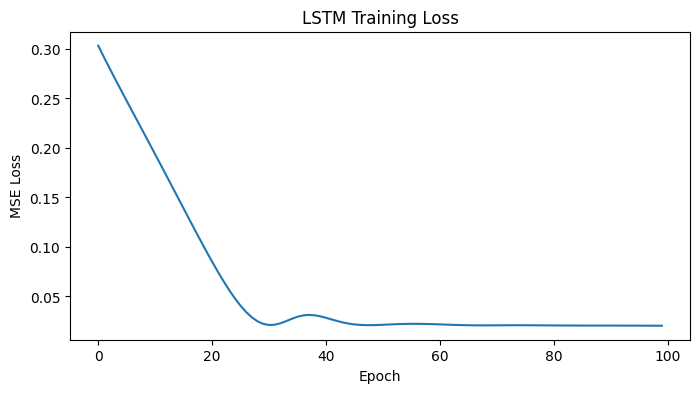

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

### 4.10 Model Evaluation

After training, the model is evaluated on the test dataset to assess its predictive performance.

In [24]:
model.eval()

with torch.no_grad():
    test_predictions = model(X_test_tensor)
    test_loss = criterion(test_predictions, y_test_tensor)

print("Test Loss:", test_loss.item())

Test Loss: 0.0248311385512352


In [25]:
predicted = test_predictions.numpy()
actual = y_test_tensor.numpy()

comparison = pd.DataFrame({
    "Actual": actual.flatten(),
    "Predicted": predicted.flatten()
})

comparison

,Actual,Predicted
0,0.652979,0.534098
1,0.550607,0.509912
2,0.550029,0.474232
3,0.620590,0.455999
4,0.326778,0.447641
5,0.229034,0.460463
6,0.138809,0.401821
7,0.584731,0.493112
8,0.596298,0.397838
9,0.620590,0.553640


To quantify performance, Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) are calculated.

In [26]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(actual, predicted)
print("MSE:", mse)

MSE: 0.0248311385512352


In [27]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 0.15757899146534476


The scatter plot below compares predicted fatigue values with actual values. The dashed diagonal line represents perfect prediction.

[0.5536402  0.54958785 0.5374128  0.53374416 0.5342815 ]
count    105.000000
mean       0.495934
std        0.046686
min        0.389248
25%        0.457039
50%        0.499125
75%        0.533744
max        0.574992
dtype: float64


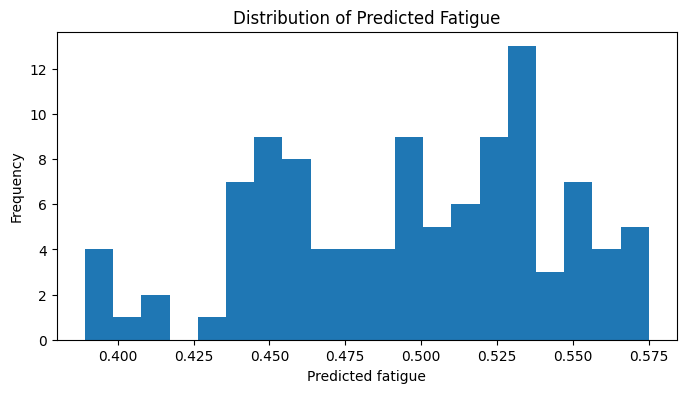

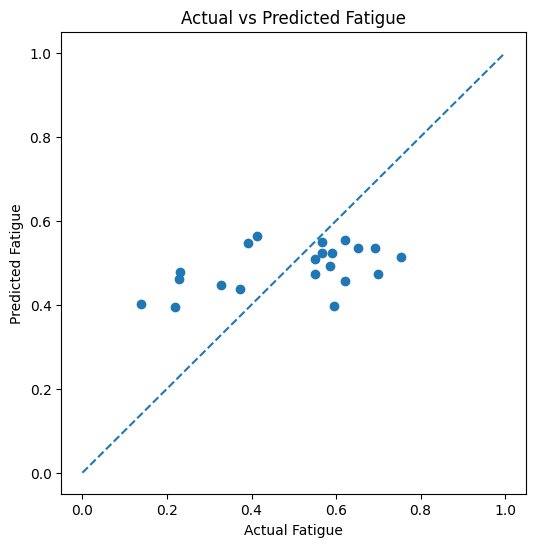

In [28]:
# Predict fatigue for all sequences after training
X_tensor_all = torch.tensor(X, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predicted_fatigue_all = model(X_tensor_all).cpu().numpy().flatten()

print(predicted_fatigue_all[:5])
print(pd.Series(predicted_fatigue_all).describe())

plt.figure(figsize=(8, 4))
plt.hist(predicted_fatigue_all, bins=20)
plt.title("Distribution of Predicted Fatigue")
plt.xlabel("Predicted fatigue")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(actual, predicted)

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("Actual Fatigue")
plt.ylabel("Predicted Fatigue")
plt.title("Actual vs Predicted Fatigue")
plt.show()

### 4.11 Interpretation of Results

The model predictions tend to cluster around the centre of the target range, indicating that the model has learned general trends but struggles to capture extreme fatigue values.

This is likely due to the limited dataset size after preprocessing and sequence construction. Despite this limitation, the LSTM successfully demonstrates the ability to model temporal relationships in activity and sleep data.

# Step 5: Reinforcement Learning

Now that the LSTM model can predict the user’s next-day fatigue score, the next step is to use this predicted fatigue as part of a decision-making system for workout recommendation.

In this section, Reinforcement Learning (RL) is introduced to recommend the next workout intensity based on the user’s current state. The idea is that the agent observes the user’s condition, such as predicted fatigue and recent activity, then selects an action corresponding to a workout recommendation.

For this project, the RL problem is simplified by defining:

State = user condition for the current day

Action = recommended workout intensity

Reward = how appropriate the recommendation is based on fatigue level

This allows the recommendation system to learn a policy that balances exercise progression with recovery.

## Step 5: Connecting LSTM predictions to RL state

In this step, the predicted fatigue values from the trained LSTM model are used to construct the state representation for the reinforcement learning environment. This ensures that workout recommendations are based on fatigue estimates derived from historical wearable data rather than randomly generated recovery values.

In [29]:
# Generate LSTM fatigue predictions for all sequences
X_tensor_all = torch.tensor(X, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predicted_fatigue_all = model(X_tensor_all).numpy().flatten()

print(predicted_fatigue_all[:5])

[0.5536402  0.54958785 0.5374128  0.53374416 0.5342815 ]


In [30]:
rl_states = []

for i in range(len(X)):
    last_day = X[i, -1, :]

    state = np.array([
        predicted_fatigue_all[i],  # predicted fatigue
        last_day[4],               # sleep_hours
        last_day[1],               # activity_load
        last_day[2],               # sedentary_minutes
    ], dtype=np.float32)

    rl_states.append(state)

rl_states = np.array(rl_states, dtype=np.float32)

print("RL states shape:", rl_states.shape)
print("Example RL state:", rl_states[0])

RL states shape: (105, 4)
Example RL state: [0.5536402  0.34527972 0.5581015  0.5371079 ]


# Step 5.1: Define the state and action space

The state should contain the main information needed for workout planning. In this prototype, the state includes:


*   predicted fatigue score from the LSTM
*   sleep hours
*   activity hours
*   sedentary minutes


The action space is kept simple and discrete:

0 = Rest

1 = Light workout

2 = Moderate workout

3 = Hard workout

In [31]:
# Workout intensity labels
action_labels = {
    0: "Rest",
    1: "Light workout",
    2: "Moderate workout",
    3: "Hard workout"
}

print(action_labels)

{0: 'Rest', 1: 'Light workout', 2: 'Moderate workout', 3: 'Hard workout'}


# Step 5.2: Create a simple workout recommendation environment

To train an RL agent, an environment is needed. This environment simulates how good or bad a workout recommendation is based on the current fatigue level.

For example:


*   if fatigue is high, recommending rest should give a higher reward
*   if fatigue is low, recommending a hard workout should give a higher reward
*   if the recommendation does not match the recovery state, the reward should be lower or negative

In [32]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class WorkoutEnvLSTM(gym.Env):
    def __init__(self, states, user_ids, true_next_fatigue, max_steps=10):
        super().__init__()

        self.states = np.array(states, dtype=np.float32)
        self.user_ids = np.array(user_ids)
        self.true_next_fatigue = np.array(true_next_fatigue, dtype=np.float32)
        self.num_states = len(states)
        self.max_steps = max_steps

        self.valid_indices = [
            i for i in range(self.num_states - 1)
            if self.user_ids[i] == self.user_ids[i + 1]
        ]

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(4,),
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(4)

        self.current_step = 0
        self.current_idx = None
        self.state = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        start_pos = np.random.randint(len(self.valid_indices))
        self.current_idx = self.valid_indices[start_pos]
        self.state = self.states[self.current_idx].copy()

        self.current_step = 0
        return self.state, {}

    def compute_reward(self, state, next_fatigue, action):
        fatigue, sleep, activity, sedentary = state

        reward = 0

        # Sleep penalty
        if sleep < 0.2:
            if action == 0:
                reward += 1.0
            else:
                reward -= 0.5

        # Fatigue logic
        if fatigue > 0.55:
            reward += {0: 1.0, 1: 0.5, 2: -0.5, 3: -1.0}[action]
        elif fatigue > 0.48:
            reward += {0: 0.3, 1: 0.7, 2: 1.0, 3: 0.2}[action]
        else:
            reward += {0: -0.5, 1: 0.2, 2: 0.6, 3: 1.0}[action]

        # Encourage recovery
        reward += 0.5 * (fatigue - next_fatigue)

        return reward

    def step(self, action):
        next_idx = self.current_idx + 1
        next_fatigue = self.true_next_fatigue[self.current_idx]

        reward = self.compute_reward(self.state, next_fatigue, action)
        self.current_step += 1

        if (
            self.current_step >= self.max_steps
            or next_idx >= self.num_states - 1
            or self.user_ids[next_idx] != self.user_ids[next_idx + 1]
        ):
            next_state = self.states[next_idx].copy()
            self.state = next_state
            self.current_idx = next_idx
            terminated = True
            truncated = False
            return next_state, reward, terminated, truncated, {}

        self.current_idx = next_idx
        self.state = self.states[self.current_idx].copy()

        terminated = False
        truncated = False
        return self.state, reward, terminated, truncated, {}

# Step 5.3: Test the environment

Before training the RL agent, it is useful to check that the environment runs correctly.

In [33]:
env = WorkoutEnvLSTM(
    states=rl_states,
    user_ids=seq_user_ids,
    true_next_fatigue=y,
    max_steps=10
)

state, _ = env.reset()
print("Initial LSTM-based state:", state)

for _ in range(5):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, _ = env.step(action)
    print(f"Action: {action_labels[action]}, Reward: {reward:.2f}, Next state: {next_state}")
    if terminated or truncated:
        break

Initial LSTM-based state: [0.4518087  0.3986014  0.44844517 0.5233359 ]
Action: Light workout, Reward: 0.13, Next state: [0.45599937 0.22814685 0.42144027 0.6717674 ]
Action: Rest, Reward: -0.58, Next state: [0.45773166 0.20541959 0.43535188 0.67329764]
Action: Hard workout, Reward: 1.01, Next state: [0.45004678 0.42307693 0.39116204 0.53328234]
Action: Moderate workout, Reward: 0.53, Next state: [0.45558923 0.33216783 0.5171849  0.53098696]
Action: Hard workout, Reward: 0.99, Next state: [0.4534675  0.39335665 0.4067103  0.55700076]


# Step 5.4: Train a DQN agent

Since the action space is discrete, a Deep Q-Network (DQN) is a suitable RL algorithm for this task.

In [34]:
!pip install stable-baselines3 -q

In [35]:
from stable_baselines3 import DQN
from stable_baselines3 import DQN

rl_model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=5e-4,
    buffer_size=5000,
    learning_starts=100,
    batch_size=32,
    gamma=0.95,
    train_freq=1,
    target_update_interval=200,
    exploration_fraction=0.3,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    seed=42
)

rl_model.learn(total_timesteps=5000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 5.25     |
|    ep_rew_mean      | 0.954    |
|    exploration_rate | 0.987    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2256     |
|    time_elapsed     | 0        |
|    total_timesteps  | 21       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4.5      |
|    ep_rew_mean      | 0.66     |
|    exploration_rate | 0.977    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1790     |
|    time_elapsed     | 0        |
|    total_timesteps  | 36       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4.17     |
|    ep_rew_mean      | 0.373  

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4.46     |
|    ep_rew_mean      | 0.917    |
|    exploration_rate | 0.932    |
| time/               |          |
|    episodes         | 24       |
|    fps              | 894      |
|    time_elapsed     | 0        |
|    total_timesteps  | 107      |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.199    |
|    n_updates        | 6        |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4.43     |
|    ep_rew_mean      | 1.01     |
|    exploration_rate | 0.921    |
| time/               |          |
|    episodes         | 28       |
|    fps              | 538      |
|    time_elapsed     | 0        |
|    total_timesteps  | 124      |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.165    |
|    n_updates      

# Step 5.5: Test the trained RL agent

After training, the agent can be tested by allowing it to choose actions based on the current state.

In [36]:
test_env = WorkoutEnvLSTM(
    states=rl_states,
    user_ids=seq_user_ids,
    true_next_fatigue=y,
    max_steps=10
)

state, _ = test_env.reset()

print("Testing trained RL agent with LSTM-based states:\n")

for step in range(10):
    action, _ = rl_model.predict(state, deterministic=True)
    action = int(action)

    next_state, reward, terminated, truncated, _ = test_env.step(action)

    print(f"Day {step+1}")
    print("State:", state)
    print("Recommended action:", action_labels[action])
    print("Reward:", reward)
    print("-" * 40)

    state = next_state

    if terminated or truncated:
        break

Testing trained RL agent with LSTM-based states:

Day 1
State: [0.4881497  0.4729021  0.47954175 0.42846212]
Recommended action: Light workout
Reward: 0.69335186
----------------------------------------
Day 2
State: [0.49311167 0.50874126 0.5507365  0.37490436]
Recommended action: Light workout
Reward: 0.6541903
----------------------------------------
Day 3
State: [0.5027667  0.46153846 0.62438625 0.39556235]
Recommended action: Light workout
Reward: 0.69719017
----------------------------------------
Day 4
State: [0.51057345 0.5008741  0.5531915  0.441469  ]
Recommended action: Light workout
Reward: 0.7924758
----------------------------------------


# Step 5.6: Generate a workout recommendation from a user state

This section shows how the trained RL model can be used to output a workout recommendation from a given state.

In [37]:
# Take a real sequence from dataset
sample_sequence = torch.tensor(X[0:1], dtype=torch.float32)

model.eval()
with torch.no_grad():
    predicted_fatigue = model(sample_sequence).item()

last_day = X[0, -1, :]

sample_state = np.array([
    predicted_fatigue,
    last_day[4],   # sleep_hours (scaled)
    last_day[1],   # activity_load (scaled)
    last_day[2],   # sedentary_minutes (scaled)
], dtype=np.float32)

action, _ = rl_model.predict(sample_state, deterministic=True)
action = int(np.asarray(action).item())

print("End-to-end recommendation")
print("Predicted fatigue:", sample_state[0])
print("Sleep:", sample_state[1])
print("Activity load:", sample_state[2])
print("Sedentary:", sample_state[3])
print("Recommended workout:", action_labels[action])




all_actions = []

for i in range(len(rl_states)):
    state = rl_states[i]
    action, _ = rl_model.predict(state, deterministic=True)
    action = int(action)
    all_actions.append(action)

action_df = pd.DataFrame({
    "fatigue": rl_states[:, 0],
    "sleep": rl_states[:, 1],
    "activity_load": rl_states[:, 2],
    "sedentary": rl_states[:, 3],
    "action": all_actions,
    "action_label": [action_labels[a] for a in all_actions]
})

print(action_df.head(20))
print(action_df["action_label"].value_counts())


End-to-end recommendation
Predicted fatigue: 0.5536402
Sleep: 0.34527972
Activity load: 0.5581015
Sedentary: 0.5371079
Recommended workout: Moderate workout
     fatigue     sleep  activity_load  sedentary  action      action_label
0   0.553640  0.345280       0.558101   0.537108       2  Moderate workout
1   0.549588  0.305070       0.528642   0.580719       2  Moderate workout
2   0.537413  0.277098       0.532733   0.615914       2  Moderate workout
3   0.533744  0.502622       0.557283   0.439939       1     Light workout
4   0.534281  0.405594       0.636661   0.454476       1     Light workout
5   0.546383  0.328671       0.651391   0.532517       1     Light workout
6   0.558580  0.285839       0.720131   0.516450       1     Light workout
7   0.555346  0.368007       0.547463   0.517980       1     Light workout
8   0.541943  0.425699       0.450900   0.517215       2  Moderate workout
9   0.408025  0.380245       0.176759   0.651109       3      Hard workout
10  0.397838  0.37

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#Step 6: LLM User Interface for Personalised Workout Recommendations

In the previous section, the reinforcement learning agent generated a workout recommendation based on the user’s current state, including predicted fatigue, sleep, and activity load. However, the raw action output alone is not very user-friendly.

To improve usability, a Large Language Model (LLM) is added as the interface layer of the system. The purpose of the LLM is to translate the model outputs into natural-language coaching feedback that is easier for a user to understand. In this project, the LLM does not replace the LSTM or RL components. Instead, it explains the recommendation in a more interpretable and personalised way.

The LLM interface receives:

- the predicted fatigue score
- the recent sleep duration
- the recent activity load
- the recommended workout action from the RL model

It then produces:

- a short explanation of why that workout was recommended like a coaching-style summary for the user
- a suggested intensity or caution note where appropriate

This creates the full pipeline:

Fitbit data → LSTM fatigue prediction → RL workout recommendation → LLM user explanation

#Step 6.1: Install and import required files


In [38]:
from google import genai
from google.colab import userdata
from IPython.display import Markdown, display
import numpy as np

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#Step 6.2: Set up the API client

The Gemini API is used to generate natural-language workout explanations. The API key is stored securely in Colab Secrets under the name GEMINI_API_KEY.

In [44]:
client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))

#Step 6.3: Define workout labels

These labels convert the RL model output into readable workout names.

In [45]:
action_labels = {
    0: "Rest",
    1: "Light workout",
    2: "Moderate workout",
    3: "Hard workout"
}

#Step 6.4: Create a helper function to display Markdown nicely

This makes the notebook output cleaner and easier to read.

In [46]:
def to_markdown(text):
    display(Markdown(text))

#Step 6.5: Create the LLM explanation function

This function sends the user state and the RL recommendation to Gemini, which returns a coaching-style explanation.

In [47]:
def generate_workout_explanation(predicted_fatigue, sleep_hours, activity_load, sedentary_minutes, action):
    workout_label = action_labels[action]

    prompt = f"""
You are a helpful fitness coaching assistant.

A machine learning system has analysed a user's recent fitness data and recommended a workout.

User state:
- Predicted fatigue score: {predicted_fatigue:.2f} (0 = low fatigue, 1 = high fatigue)
- Sleep hours: {sleep_hours:.2f}
- Activity load: {activity_load:.2f}
- Sedentary minutes: {sedentary_minutes:.2f}

Recommended workout:
- {workout_label}

Write a short response for the user using this exact structure:

### Recommendation
[Write one short sentence]

### Reason
[Explain briefly why this workout was recommended]

### Coaching note
[Give one short practical piece of advice]

Keep the tone supportive, clear, and concise.
"""

    response = client.models.generate_content(
        model="gemini-2.0-flash",
        contents=prompt
    )

    return response.text

#Step 6.6: Test the Gemini explanation with a sample input

This step checks whether the Gemini API is working correctly.

In [48]:
sample_state = np.array([0.78, 5.8, 185.0, 720.0], dtype=np.float32)
sample_action = 0  # Rest

llm_text = generate_workout_explanation(
    predicted_fatigue=sample_state[0],
    sleep_hours=sample_state[1],
    activity_load=sample_state[2],
    sedentary_minutes=sample_state[3],
    action=sample_action
)

to_markdown(llm_text)

ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\nPlease retry in 33.0424903s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.goog

#Step 6.7: Use the LLM together with the RL output

This section shows how the Gemini explanation can be generated from a workout recommendation produced by the RL model.

In [ ]:
# Select one real state from the RL state array
sample_index = 0
state = rl_states[sample_index]

# Get the RL model recommendation
action, _ = rl_model.predict(state, deterministic=True)

print("Recommended workout:", action_labels[action])

llm_text = generate_workout_explanation(
    predicted_fatigue=state[0],
    sleep_hours=state[1],
    activity_load=state[2],
    sedentary_minutes=state[3],
    action=action
)

to_markdown(llm_text)

In [ ]:
def inverse_transform_state(state, scaler_X):
    """
    Convert one RL state from scaled values back to original feature units.
    Expected order:
    [predicted_fatigue, sleep_hours, activity_load, sedentary_minutes]
    """
    # state[1:] corresponds to scaled input features from the last time step
    feature_part = np.array(state[1:]).reshape(1, -1)
    original_features = scaler_X.inverse_transform(feature_part)[0]

    return {
        "predicted_fatigue": float(state[0]),   # already model output, usually keep as scaled fatigue score
        "sleep_hours": float(original_features[0]),
        "activity_load": float(original_features[1]),
        "sedentary_minutes": float(original_features[2])
    }

#Step 6.8: Create a full user-facing recommendation display

This function combines the state values, workout recommendation, and Gemini explanation into one final notebook output.

In [ ]:
def display_user_recommendation(state, action, scaler_X=None):
    if scaler_X is not None:
        readable = inverse_transform_state(state, scaler_X)
        fatigue = readable["predicted_fatigue"]
        sleep_hours = readable["sleep_hours"]
        activity_load = readable["activity_load"]
        sedentary_minutes = readable["sedentary_minutes"]
    else:
        fatigue = state[0]
        sleep_hours = state[1]
        activity_load = state[2]
        sedentary_minutes = state[3]

    explanation = generate_workout_explanation(
        predicted_fatigue=fatigue,
        sleep_hours=sleep_hours,
        activity_load=activity_load,
        sedentary_minutes=sedentary_minutes,
        action=action
    )

    print("=== Personalised Workout Recommendation ===")
    print(f"Predicted fatigue score : {fatigue:.2f}")
    print(f"Sleep hours             : {sleep_hours:.2f}")
    print(f"Activity load           : {activity_load:.2f}")
    print(f"Sedentary minutes       : {sedentary_minutes:.2f}")
    print(f"Recommended workout     : {action_labels[action]}")
    print()

    to_markdown(explanation)

#Step 6.9: Test the full recommendation interface

In [ ]:
test_state = np.array([0.35, 7.4, 95.0, 520.0], dtype=np.float32)
test_action = 3  # Hard workout

display_user_recommendation(test_state, test_action)

#Step 6.10: Interpretation

The Gemini model acts as the final user interface layer of the personalised workout recommendation system. The LSTM predicts fatigue, the reinforcement learning model selects an appropriate workout, and the LLM translates this recommendation into natural-language feedback.

This improves interpretability because the user does not only see a label such as “Moderate workout,” but also receives an explanation and a coaching note. As a result, the overall system becomes more human-centred and easier to understand.

#Step 6.11: Optional fallback without API

If the Gemini API is unavailable, a local fallback function can be used to simulate the LLM interface. This function does not require internet access or an API key. Instead, it generates coaching-style responses using simple rules based on the predicted fatigue score and the recommended workout.

Although this fallback is not a true large language model, it preserves the same user-facing interface structure and allows the recommendation system to remain fully functional.

In [49]:
def generate_workout_explanation_fallback(predicted_fatigue, sleep_hours, activity_load, sedentary_minutes, action):
    workout_label = action_labels[action]

    # Determine fatigue category
    if predicted_fatigue >= 0.7:
        fatigue_status = "high"
    elif predicted_fatigue >= 0.4:
        fatigue_status = "moderate"
    else:
        fatigue_status = "low"

    # Reason component using more than one variable
    if fatigue_status == "high":
        reason = (
            f"Your predicted fatigue is high, and your recent recovery appears limited. "
            f"With {sleep_hours:.1f} hours of sleep and an activity load of {activity_load:.1f}, "
            f"a lower-intensity recommendation is more appropriate today."
        )
        coaching = "Prioritise recovery today with rest, hydration, and light mobility if needed."

    elif fatigue_status == "moderate":
        reason = (
            f"Your fatigue level is moderate, which suggests that you can still train, "
            f"but a balanced session is more suitable than a highly demanding workout. "
            f"Your recent sleep and activity pattern indicates a need for controlled effort."
        )
        coaching = "Train steadily today and avoid increasing intensity too aggressively."

    else:
        reason = (
            f"Your predicted fatigue is low, suggesting that you are relatively well recovered. "
            f"With {sleep_hours:.1f} hours of sleep and manageable recent workload, "
            f"your body is in a better condition for a more challenging session."
        )
        coaching = "This is a good day to train with confidence while maintaining proper pacing and form."

    return f"""
### Recommendation
A **{workout_label.lower()}** is recommended today.

### Reason
{reason}

### Coaching note
{coaching}
"""

#Step 6.12: Test the fallback explanation

In [50]:
fallback_text = generate_workout_explanation_fallback(
    predicted_fatigue=0.78,
    sleep_hours=5.8,
    activity_load=185.0,
    sedentary_minutes=720.0,
    action=0
)

to_markdown(fallback_text)


### Recommendation
A **rest** is recommended today.

### Reason
Your predicted fatigue is high, and your recent recovery appears limited. With 5.8 hours of sleep and an activity load of 185.0, a lower-intensity recommendation is more appropriate today.

### Coaching note
Prioritise recovery today with rest, hydration, and light mobility if needed.


#Step 6.13: Add a display function using the fallback mode

In [51]:
def display_user_recommendation_fallback(state, action):
    fatigue = state[0]
    sleep_hours = state[1]
    activity_load = state[2]
    sedentary_minutes = state[3]

    explanation = generate_workout_explanation_fallback(
        predicted_fatigue=fatigue,
        sleep_hours=sleep_hours,
        activity_load=activity_load,
        sedentary_minutes=sedentary_minutes,
        action=action
    )

    print("=== Personalised Workout Recommendation (Fallback Mode) ===")
    print(f"Predicted fatigue score : {fatigue:.2f}")
    print(f"Sleep hours             : {sleep_hours:.2f}")
    print(f"Activity load           : {activity_load:.2f}")
    print(f"Sedentary minutes       : {sedentary_minutes:.2f}")
    print(f"Recommended workout     : {action_labels[action]}")
    print()

    to_markdown(explanation)

#Step 6.14: Test the full fallback interface

In [52]:
test_state = np.array([0.32, 7.6, 100.0, 500.0], dtype=np.float32)
test_action = 3  # Hard workout

display_user_recommendation_fallback(test_state, test_action)

=== Personalised Workout Recommendation (Fallback Mode) ===
Predicted fatigue score : 0.32
Sleep hours             : 7.60
Activity load           : 100.00
Sedentary minutes       : 500.00
Recommended workout     : Hard workout




### Recommendation
A **hard workout** is recommended today.

### Reason
Your predicted fatigue is low, suggesting that you are relatively well recovered. With 7.6 hours of sleep and manageable recent workload, your body is in a better condition for a more challenging session.

### Coaching note
This is a good day to train with confidence while maintaining proper pacing and form.


#Step 6.15: Unified Explaination Interface

In [53]:
USE_GEMINI = False  # Set to True only if Gemini API is available and configured

def generate_workout_explanation(predicted_fatigue, sleep_hours, activity_load, sedentary_minutes, action):
    if USE_GEMINI:
        workout_label = action_labels[action]

        prompt = f"""
You are a helpful fitness coaching assistant.

A machine learning system has analysed a user's recent fitness data and recommended a workout.

User state:
- Predicted fatigue score: {predicted_fatigue:.2f} (0 = low fatigue, 1 = high fatigue)
- Sleep hours: {sleep_hours:.2f}
- Activity load: {activity_load:.2f}
- Sedentary minutes: {sedentary_minutes:.2f}

Recommended workout:
- {workout_label}

Write a short response for the user using this exact structure:

### Recommendation
[Write one short sentence]

### Reason
[Explain briefly why this workout was recommended]

### Coaching note
[Give one short practical piece of advice]

Keep the tone supportive, clear, and concise.
"""

        response = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=prompt
        )

        return response.text

    else:
        return generate_workout_explanation_fallback(
            predicted_fatigue=predicted_fatigue,
            sleep_hours=sleep_hours,
            activity_load=activity_load,
            sedentary_minutes=sedentary_minutes,
            action=action
        )

#Step 6.16: Final test of unified interface

In [54]:
test_state = np.array([0.65, 6.2, 145.0, 640.0], dtype=np.float32)
test_action = 2  # Moderate workout

final_text = generate_workout_explanation(
    predicted_fatigue=test_state[0],
    sleep_hours=test_state[1],
    activity_load=test_state[2],
    sedentary_minutes=test_state[3],
    action=test_action
)

to_markdown(final_text)


### Recommendation
A **moderate workout** is recommended today.

### Reason
Your fatigue level is moderate, which suggests that you can still train, but a balanced session is more suitable than a highly demanding workout. Your recent sleep and activity pattern indicates a need for controlled effort.

### Coaching note
Train steadily today and avoid increasing intensity too aggressively.


#Step 6.17: End-to-end demonstration of the full system

The following code demonstrates the full recommendation pipeline. A real state from the reinforcement learning input is selected, the RL agent generates a workout recommendation, and the explanation layer converts this recommendation into user-facing coaching feedback.

In [55]:
sample_index = 0
state = rl_states[sample_index]

action, _ = rl_model.predict(state, deterministic=True)

display_user_recommendation(state, action)

NameError: name 'display_user_recommendation' is not defined